# 03b — Self-Supervised Pre-Training (SupCon)

Train the ST-GCN encoder on **ShuttleSet** skeletons using **Supervised Contrastive** loss.

- **Composite labels:** `shot_type × 2 + hitter_side` — a smash by the top-court player (P0)
  and a smash by the bottom-court player (P1) are different SupCon classes, because their
  skeleton node positions are completely different
- Only uses the **train split** (labels + hitter info required)
- Subsumes SimCLR when every sample has a unique label

Saved checkpoint: `ssl_pretrained_supcon_{layer}.pt`

In [ ]:
import os, sys, zipfile
from pathlib import Path

# ── Colab detection ───────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    DRIVE_ROOT   = Path('/content/drive/MyDrive/Baddiev2')
    PROJECT_PATH = Path('/content/Baddiev2')
    ZIP_PATH     = DRIVE_ROOT / 'baddiev2_colab.zip'

    if not (PROJECT_PATH / 'src').exists():
        print('Extracting project files...')
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(PROJECT_PATH)
        print(f'Extracted to {PROJECT_PATH}')
    else:
        print('Project already extracted.')

    sys.path.insert(0, str(PROJECT_PATH))
    os.chdir(PROJECT_PATH)

    import src.config as _cfg
    _cfg.MODELS_DIR            = DRIVE_ROOT / 'models'
    _cfg.RESULTS_DIR           = DRIVE_ROOT / 'results'
    _cfg.SS_SKELETONS_GDINO    = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_skeletons_gdino'
    _cfg.FB_SKELETONS_GDINO_V2 = DRIVE_ROOT / 'datasets_preprocessing' / 'finebadminton_skeletons_gdino_v2'
    _cfg.FB_ANNOTATIONS        = (
        DRIVE_ROOT / 'datasets' / 'FineBadminton-dataset' / 'dataset' /
        'transformed_combined_rounds_output_en_evals_translated.json'
    )
    _cfg.SS_CSV_ROOT   = DRIVE_ROOT / 'datasets' / 'ShuttleSet' / 'set'
    _cfg.SS_MATCH_CSV  = _cfg.SS_CSV_ROOT / 'match.csv'
    _cfg.SS_SPLIT_JSON = PROJECT_PATH / 'datasets_preprocessing' / 'shuttleset_split.json'

    _cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
    _cfg.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    print(f'Drive root   : {DRIVE_ROOT}')
    print(f'Models dir   : {_cfg.MODELS_DIR}')
    print(f'SS skeletons : {_cfg.SS_SKELETONS_GDINO}')
    print(f'SS CSV root  : {_cfg.SS_CSV_ROOT}')
    print(f'SS CSV exists: {_cfg.SS_CSV_ROOT.exists()}')
else:
    sys.path.insert(0, os.path.abspath('..'))
    DRIVE_ROOT = Path('..')
    print('Local run — using paths from config.py')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project already extracted.
Drive root   : /content/drive/MyDrive/Baddiev2
Models dir   : /content/drive/MyDrive/Baddiev2/models
SS skeletons : /content/drive/MyDrive/Baddiev2/datasets_preprocessing/shuttleset_skeletons_gdino
SS CSV root  : /content/drive/MyDrive/Baddiev2/datasets/ShuttleSet/set
SS CSV exists: True


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.config import *
from src.data.graph_builder import GraphBuilder
from src.data.dataset import ShuttleSetDataset
from src.models.stgcn_model import STGCN
from src.models.simclr_loss import (
    SupConLoss, ProjectionHead, SkeletonAugmentor
)

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f"Device: {device}")

Device: cuda


## 1. Configuration

In [ ]:
cfg = get_config('ssl_supcon')

# ── Feature layer toggle ──────────────────────────────────────────────────────
FEATURE_LAYER = 'L2'    # 'L0' | 'L1' | 'L2' | 'L3'
# ─────────────────────────────────────────────────────────────────────────────

# ── Override for quick test runs (comment out if want to use config.py) ──────────────
cfg.ssl.epochs = 100
cfg.data.shot_window = 32   # T=32 frames per shot (covers P75 of shot intervals)
cfg.stgcn.in_channels = FEATURE_DIMS[FEATURE_LAYER]
cfg.ssl.temperature = 0.2
cfg.ssl.jitter_std     = 0.02     # was 0.06 — gentler Gaussian noise
cfg.ssl.mask_ratio     = 0.15     # was 0.40 — keep ~85% of joints (graph stays connected)
cfg.ssl.speed_range    = 0.20     # was 0.30 — narrower temporal resampling
cfg.ssl.rotation_range = 10       # was 25   — subtle rotation, preserves court orientation

# ─────────────────────────────────────────────────────────────────────────────

feature_dim = FEATURE_DIMS[FEATURE_LAYER]
cfg.stgcn.in_channels = feature_dim

print(f"Feature layer : {FEATURE_LAYER} ({feature_dim} features/node)")
print(f"SSL method    : SupCon (composite: shot_type × 2 + hitter_side)")
print(f"\nEncoder: ST-GCN")
print(f"  in_channels  : {cfg.stgcn.in_channels}")
print(f"  num_nodes    : {cfg.stgcn.num_nodes}")
print(f"  embedding_dim: {cfg.stgcn.embedding_dim}")
print(f"\nSSL config:")
print(f"  temperature  : {cfg.ssl.temperature}")
print(f"  epochs       : {cfg.ssl.epochs}")
print(f"  batch_size   : {cfg.ssl.batch_size}")

Feature layer : L2 (9 features/node)
SSL method    : SupCon (composite: shot_type × 2 + hitter_side)

Encoder: ST-GCN
  in_channels  : 9
  num_nodes    : 34
  embedding_dim: 256

SSL config:
  temperature  : 0.2
  epochs       : 100
  batch_size   : 64


## 2. Build Model Components

In [ ]:
# Build graph adjacency
graph_builder = GraphBuilder(
    use_inter_player=cfg.ablation.use_inter_player,
    single_player=cfg.ablation.single_player,
)
adjacency = graph_builder.build_adjacency().to(device)
print(f"Adjacency: {adjacency.shape}")

# Build encoder
encoder = STGCN(
    in_channels=cfg.stgcn.in_channels,
    num_nodes=cfg.stgcn.num_nodes,
    adjacency=adjacency,
    num_layers=cfg.stgcn.num_layers,
    base_channels=cfg.stgcn.base_channels,
    embedding_dim=cfg.stgcn.embedding_dim,
    temporal_kernel=cfg.stgcn.temporal_kernel,
    dropout=cfg.stgcn.dropout,
).to(device)

# Projection head
projector = ProjectionHead(
    embedding_dim=cfg.stgcn.embedding_dim,
    hidden_dim=cfg.ssl.projection_hidden,
    projection_dim=cfg.ssl.projection_dim,
).to(device)

# SupCon loss — uses composite labels (shot_type * 2 + hitter_side) as positives
contrastive_loss = SupConLoss(temperature=cfg.ssl.temperature)
print(f"Loss: SupConLoss (composite: shot_type × 2 + hitter_side)")

augmentor = SkeletonAugmentor(
    jitter_std=cfg.ssl.jitter_std,
    mask_ratio=cfg.ssl.mask_ratio,
    speed_range=cfg.ssl.speed_range,
    rotation_range=cfg.ssl.rotation_range,
)

params = list(encoder.parameters()) + list(projector.parameters())
optimizer = optim.AdamW(params, lr=cfg.ssl.lr, weight_decay=cfg.ssl.weight_decay)

total_params = sum(p.numel() for p in encoder.parameters())
print(f"\nEncoder parameters: {total_params:,}")
print(f"Total trainable   : {sum(p.numel() for p in params):,}")

Adjacency: torch.Size([3, 34, 34])
Loss: SupConLoss (composite: shot_type × 2 + hitter_side)

Encoder parameters: 3,083,199
Total trainable   : 3,182,399


## 3. Load Data

SupCon uses only the **train split** since it requires shot-type labels.

In [ ]:
## Inspect available skeletons before loading dataset
from src.config import SS_SKELETONS_GDINO

skel_root = SS_SKELETONS_GDINO
print(f"Skeleton dir: {skel_root}")
print(f"Exists: {skel_root.exists()}\n")

match_dirs = sorted([d for d in skel_root.iterdir() if d.is_dir()]) if skel_root.exists() else []
print(f"{'Match':<65} {'skeletons.npy':>14} {'frame_nums.npy':>15} {'Frames':>8}")
print("-" * 105)
total_frames = 0
for d in match_dirs:
    has_sk = (d / 'skeletons.npy').exists()
    has_fn = (d / 'frame_nums.npy').exists()
    n_frames = 0
    if has_fn:
        n_frames = len(np.load(str(d / 'frame_nums.npy')))
        total_frames += n_frames
    sk_str = f"{np.load(str(d / 'skeletons.npy')).shape}" if has_sk else "missing"
    fn_str = str(n_frames) if has_fn else "missing"
    print(f"  {d.name:<63} {sk_str:>14} {fn_str:>15} {n_frames:>8}")

print(f"\nTotal matches: {len(match_dirs)}  |  Total frames with skeletons: {total_frames:,}")

Skeleton dir: /content/drive/MyDrive/Baddiev2/datasets_preprocessing/shuttleset_skeletons_gdino
Exists: True

Match                                                              skeletons.npy  frame_nums.npy   Frames
---------------------------------------------------------------------------------------------------------
  1 empty                                                                missing         missing        0
  2 bad quality                                                          missing         missing        0
  Anders_ANTONSEN_Jonatan_CHRISTIE Indonesia_Masters_2020_QuarterFinals  (2, 1018, 34)            1018     1018
  Anders_Antonsen_Viktor_Axelsen_HSBC_BWF_WORLD_TOUR_FINALS_2020_Finals  (2, 6715, 34)            6715     6715
  Anthony_Sinisuka_GINTING_Anders_ANTONSEN_Indonesia_Masters_2020_Final  (2, 5347, 34)            5347     5347
  Anthony_Sinisuka_GINTING_Viktor_AXELSEN _Indonesia_Masters_2020_SemiFinals  (2, 3307, 34)            3307     3307
  Anthony_Sin

In [ ]:
from src.config import SS_SKELETONS_GDINO, SS_SPLIT_JSON

# ── Hardcoded train split (matches with GDINO skeletons extracted) ───────────
TRAIN_MATCHES = {
    "Anders_Antonsen_Viktor_Axelsen_HSBC_BWF_WORLD_TOUR_FINALS_2020_Finals",
    "Anthony_Sinisuka_GINTING_Anders_ANTONSEN_Indonesia_Masters_2020_Final",
    "Anthony_Sinisuka_GINTING_Viktor_AXELSEN _Indonesia_Masters_2020_SemiFinals",
    "CHOU_Tien_Chen_Anders_ANTONSEN_Fuzhou_Open_2019_Semi-finals",
    "Ng_Ka_Long_Angus_Lee_Cheuk_Yiu_YONEX_Thailand_Open_2021_QuarterFinals",
    "Viktor_AXELSEN _SHI_Yu_Qi_All_England_Open_2020_QuarterFinals",
    "Viktor_AXELSEN_CHEN_Long_Malaysia_Masters_2020_QuarterFinals",
    "Viktor_AXELSEN_NG_Ka_Long_Angus_Malaysia_Masters_2020_SemiFinals",
}

dataset = ShuttleSetDataset(
    skeleton_dir=SS_SKELETONS_GDINO,
    shot_window=cfg.data.shot_window,
    feature_layer=FEATURE_LAYER,
    load_shot_types=True,
    split=None,  # load all, then filter below
)

# Filter to train matches only
dataset.samples = [s for s in dataset.samples
                   if Path(s['skel_dir']).name in TRAIN_MATCHES]

# ── Build composite SupCon labels: shot_type * 2 + hitter_side ───────────────
# P0 (nodes 0-16) = top court, P1 (nodes 17-33) = bottom court — ALWAYS.
# A smash by P0 looks completely different from a smash by P1 in skeleton space,
# so they must be DIFFERENT SupCon classes. Grouping them together would pull
# apart representations that look nothing alike.
#
# Composite label = shot_type_idx * 2 + (0 if hitter=='top' else 1)
# Samples without valid hitter info get shot_type_idx = None → filtered out as -1.

n_valid, n_no_hitter, n_no_type = 0, 0, 0
for s in dataset.samples:
    st = s.get('shot_type_idx')
    hitter = s.get('hitter', '')
    if st is not None and hitter in ('top', 'bottom'):
        s['shot_type_idx'] = st * 2 + (0 if hitter == 'top' else 1)
        n_valid += 1
    elif st is not None:
        # No hitter info → can't form correct SupCon groups → exclude
        s['shot_type_idx'] = None
        n_no_hitter += 1
    else:
        n_no_type += 1

n_composite = len(set(s['shot_type_idx'] for s in dataset.samples if s.get('shot_type_idx') is not None))
print(f"Dataset size: {len(dataset)} samples (train split, hardcoded)")
print(f"  Valid composite labels: {n_valid}")
print(f"  Excluded (no hitter):   {n_no_hitter}")
print(f"  Excluded (no shot type):{n_no_type}")
print(f"  Unique composite classes: {n_composite}  (shot_types × 2 sides)")

# Sanity check
sample = dataset[0]
x, lbl = sample if isinstance(sample, tuple) else (sample, None)
has_data = x.abs().sum() > 0
print(f"\nSample shape: {x.shape}, composite_label: {lbl}, has_data: {has_data}")

# Check label availability
n_labeled = sum(1 for i in range(min(500, len(dataset)))
                if dataset[i][1] >= 0)
print(f"Shots with valid composite label (first {min(500, len(dataset))} samples): {n_labeled}/{min(500, len(dataset))}")
if n_labeled == 0:
    print("WARNING: No labels found — check dataset CSV loading + hitter map")

[INFO] ShuttleSet split='None': 8362 shots from whole-match skeletons across 8 match(es)
Dataset size: 4901 samples (train split, hardcoded)
  Valid composite labels: 4809
  Excluded (no hitter):   14
  Excluded (no shot type):78
  Unique composite classes: 30  (shot_types × 2 sides)

Sample shape: torch.Size([9, 32, 34]), composite_label: 1, has_data: True
Shots with valid composite label (first 500 samples): 500/500


In [ ]:
def ssl_collate(batch):
    """Collate (x, composite_label) tuples for SupCon training."""
    xs, labels = zip(*batch)
    return torch.stack(xs), torch.tensor(labels, dtype=torch.long)

dataloader = DataLoader(
    dataset,
    batch_size=cfg.ssl.batch_size,
    shuffle=True,
    num_workers=0,   # set to 4 on Colab
    pin_memory=True,
    drop_last=True,
    collate_fn=ssl_collate,
)
print(f"Batches per epoch: {len(dataloader)}")

Batches per epoch: 76


## 3b. SupCon Visualisations

Four diagnostic views before training:

1. **Positive-pair structure** — SupCon vs SimCLR side-by-side: which cells in the 2B x 2B similarity matrix act as "pull together"
2. **Training signal richness** — how many positives each anchor gets (SupCon >> SimCLR)
3. **Intra-class skeleton consistency** — do shots with the same composite label (shot_type + hitter side) actually share similar posture? If within-row variance is high, SupCon's positive-pairing assumption may not hold

> These cells are diagnostic only and do not affect training.

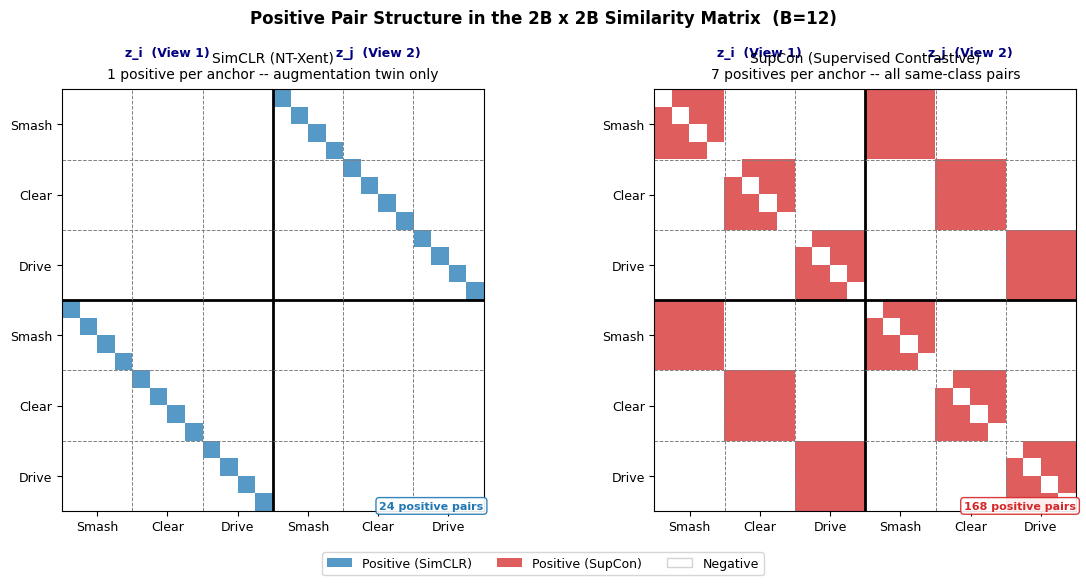

Saved: results/ssl_supcon_viz_positive_pair_structure.png


In [ ]:
# ── Viz 1: Positive-pair structure — SimCLR vs SupCon ─────────────────────────
import matplotlib.patches as mpatches

_NPC, _CLS = 4, ['Smash', 'Clear', 'Drive']
_B   = _NPC * len(_CLS)
_lbl = np.concatenate([np.repeat(np.arange(len(_CLS)), _NPC)] * 2)

_sc = np.zeros((2*_B, 2*_B), bool)   # SimCLR: augmentation twins only
for _i in range(_B):
    _sc[_i, _i+_B] = _sc[_i+_B, _i] = True

_sp = (_lbl[:,None] == _lbl[None,:])  # SupCon: all same-class
np.fill_diagonal(_sp, False)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5.5))
fig.suptitle(f'Positive Pair Structure in the 2B x 2B Similarity Matrix  (B={_B})',
             fontsize=12, fontweight='bold')

for ax, title, sub, mask, col in [
    (ax0, 'SimCLR (NT-Xent)', '1 positive per anchor -- augmentation twin only', _sc, '#1f77b4'),
    (ax1, 'SupCon (Supervised Contrastive)', f'{2*_NPC-1} positives per anchor -- all same-class pairs', _sp, '#d62728'),
]:
    bg = np.ones((2*_B, 2*_B, 4))
    bg[mask] = [int(col[1:3],16)/255, int(col[3:5],16)/255, int(col[5:7],16)/255, 0.75]
    ax.imshow(bg, interpolation='none')
    ax.axhline(_B-0.5, color='black', lw=2)
    ax.axvline(_B-0.5, color='black', lw=2)
    for c in range(1, len(_CLS)):
        for off in [0, _B]:
            p = off + c*_NPC - 0.5
            ax.axhline(p, color='gray', lw=0.7, ls='--')
            ax.axvline(p, color='gray', lw=0.7, ls='--')
    tks = [off + c*_NPC + _NPC/2 - 0.5 for off in [0,_B] for c in range(len(_CLS))]
    ax.set_xticks(tks); ax.set_xticklabels(_CLS*2, fontsize=9)
    ax.set_yticks(tks); ax.set_yticklabels(_CLS*2, fontsize=9)
    ax.text(_B/2-0.5,    -2.4, 'z_i  (View 1)', ha='center', fontsize=9, color='navy', fontweight='bold')
    ax.text(_B+_B/2-0.5, -2.4, 'z_j  (View 2)', ha='center', fontsize=9, color='navy', fontweight='bold')
    ax.set_title(f'{title}\n{sub}', fontsize=10, pad=8)
    ax.text(2*_B-0.5, 2*_B-0.5, f'{int(mask.sum())} positive pairs',
            ha='right', va='bottom', fontsize=8, color=col, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=col, alpha=0.9))

fig.legend(handles=[
    mpatches.Patch(fc='#1f77b4', alpha=0.75, label='Positive (SimCLR)'),
    mpatches.Patch(fc='#d62728', alpha=0.75, label='Positive (SupCon)'),
    mpatches.Patch(fc='white', ec='lightgray', label='Negative'),
], loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / 'ssl_supcon_viz_positive_pair_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/ssl_supcon_viz_positive_pair_structure.png")

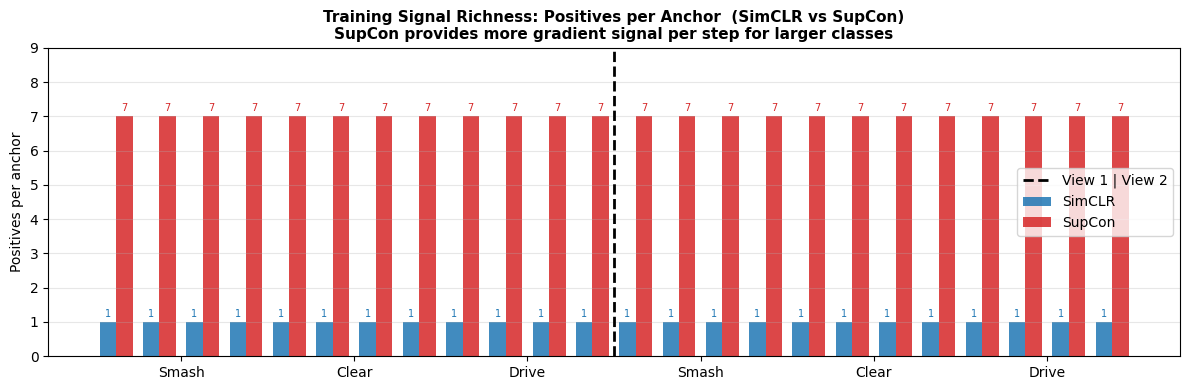

SimCLR: 1.0 positives per anchor (constant)
SupCon: 7.0 positives per anchor on average (7.0x more signal)
Saved: results/ssl_supcon_viz_training_signal.png


In [ ]:
# ── Viz 2: Training signal richness ───────────────────────────────────────────
_sc_n = np.ones(2*_B, dtype=int)
_sp_n = np.array([int((_lbl == _lbl[i]).sum()) - 1 for i in range(2*_B)])

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(2*_B)
w = 0.38
ax.bar(x - w/2, _sc_n, w, color='#1f77b4', alpha=0.85, label='SimCLR')
ax.bar(x + w/2, _sp_n, w, color='#d62728', alpha=0.85, label='SupCon')
ax.axvline(_B - 0.5, color='black', lw=2, ls='--', label='View 1 | View 2')

tks = [off + c*_NPC + _NPC/2 - 0.5 for off in [0,_B] for c in range(len(_CLS))]
ax.set_xticks(tks); ax.set_xticklabels(_CLS*2, fontsize=10)
ax.set_ylabel('Positives per anchor'); ax.set_ylim(0, max(_sp_n) + 2)
ax.set_title(
    'Training Signal Richness: Positives per Anchor  (SimCLR vs SupCon)\n'
    'SupCon provides more gradient signal per step for larger classes',
    fontsize=11, fontweight='bold',
)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')

for i, (s, sp) in enumerate(zip(_sc_n, _sp_n)):
    ax.text(x[i]-w/2, s+0.1, str(s), ha='center', va='bottom', fontsize=7, color='#1f77b4')
    ax.text(x[i]+w/2, sp+0.1, str(sp), ha='center', va='bottom', fontsize=7, color='#d62728')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ssl_supcon_viz_training_signal.png', dpi=150, bbox_inches='tight')
plt.show()

_mean_sc = _sc_n.mean(); _mean_sp = _sp_n.mean()
print(f"SimCLR: {_mean_sc:.1f} positives per anchor (constant)")
print(f"SupCon: {_mean_sp:.1f} positives per anchor on average ({_mean_sp/_mean_sc:.1f}x more signal)")
print("Saved: results/ssl_supcon_viz_training_signal.png")

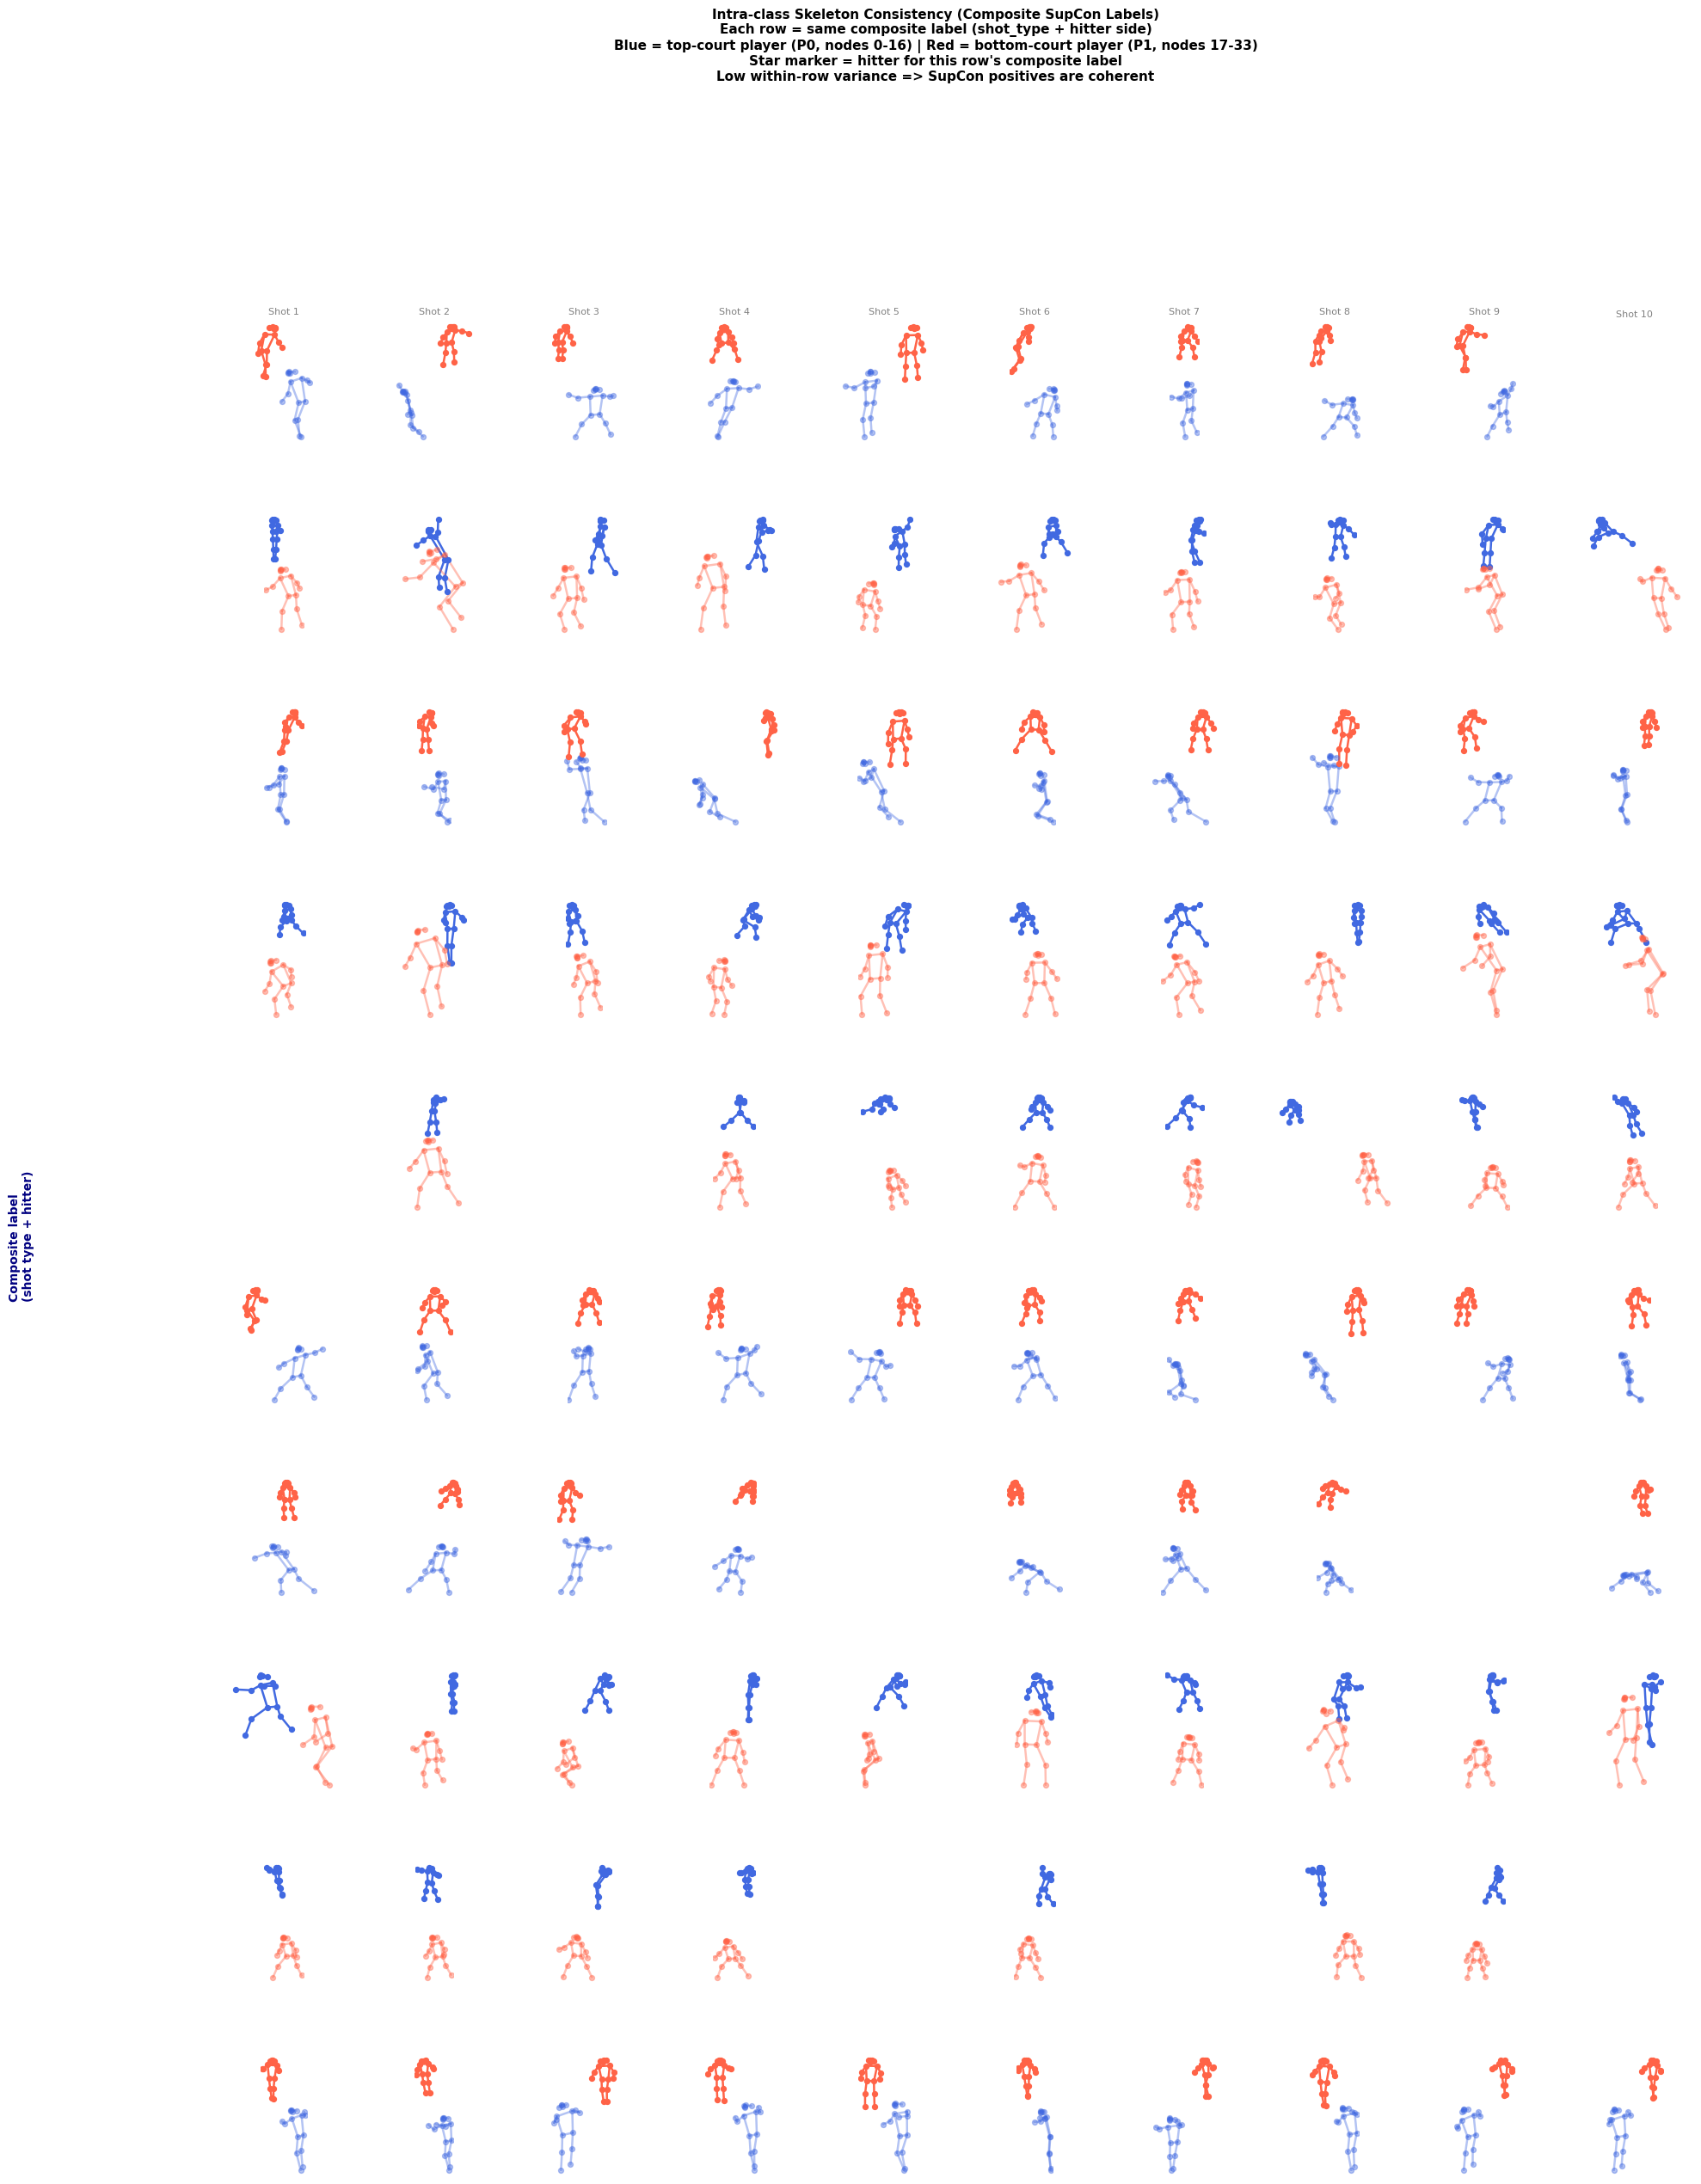


Composite classes shown (10):
  net_drop             hitter=bottom (P1)   412 samples
  net_drop             hitter=top (P0)      411 samples
  lob_lift             hitter=bottom (P1)   332 samples
  lob_lift             hitter=top (P0)      329 samples
  block                hitter=top (P0)      269 samples
  push                 hitter=bottom (P1)   266 samples
  block                hitter=bottom (P1)   259 samples
  push                 hitter=top (P0)      198 samples
  tap_smash            hitter=top (P0)      191 samples
  short_serve          hitter=bottom (P1)   190 samples

Saved: results/ssl_supcon_viz_intraclass_consistency.png

Interpretation:
  Poses look similar within a row  => SupCon hypothesis holds
  Poses look random within a row   => composite label is still too coarse


In [ ]:
# ── Viz 3: Intra-class skeleton consistency (composite labels) ────────────────
# The SupCon hypothesis: same composite label => similar skeleton posture.
# Composite label = shot_type * 2 + hitter_side, so "smash by P0 (top)"
# and "smash by P1 (bottom)" are DIFFERENT rows.
#
# What to look for:
#   - LOW intra-row variance  => hypothesis holds, SupCon positives are coherent
#   - HIGH intra-row variance => same label, very different poses => noisy gradients

import matplotlib.gridspec as gridspec
from collections import defaultdict

_COCO_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
]

def _draw_skel(ax, xy17, color, alpha=1.0):
    for j1, j2 in _COCO_EDGES:
        x1,y1 = xy17[j1]; x2,y2 = xy17[j2]
        if max(abs(x1),abs(y1),abs(x2),abs(y2)) > 1e-4:
            ax.plot([x1,x2],[-y1,-y2],'-',color=color,lw=1.8,alpha=alpha)
    for j in range(17):
        if abs(xy17[j,0])+abs(xy17[j,1]) > 1e-4:
            ax.scatter(xy17[j,0],-xy17[j,1],s=18,c=color,alpha=alpha,zorder=5)

def _get_mid(x_tensor):
    xy = x_tensor[:2, x_tensor.shape[1]//2, :].T.numpy()
    return xy[:17], xy[17:]

# ── Collect samples per composite label ──────────────────────────────────────
N_COLS   = 10
MIN_SAMPLES = 3

by_composite = defaultdict(list)
for i in range(len(dataset)):
    x, cl = dataset[i]
    if cl >= 0 and x.abs().sum() > 0:
        by_composite[cl].append(x)

available = [(cl, xs) for cl, xs in by_composite.items() if len(xs) >= MIN_SAMPLES]
available.sort(key=lambda kv: -len(kv[1]))
show_types = available[:10]

if not show_types:
    print("No labeled, non-zero samples found — run with a split that has shot-type + hitter labels.")
else:
    N_ROWS = len(show_types)
    fig = plt.figure(figsize=(N_COLS * 2.2, N_ROWS * 2.8))
    fig.suptitle(
        'Intra-class Skeleton Consistency (Composite SupCon Labels)\n'
        'Each row = same composite label (shot_type + hitter side)\n'
        'Blue = top-court player (P0, nodes 0-16) | Red = bottom-court player (P1, nodes 17-33)\n'
        'Star marker = hitter for this row\'s composite label\n'
        'Low within-row variance => SupCon positives are coherent',
        fontsize=11, fontweight='bold', y=1.01,
    )

    gs = gridspec.GridSpec(N_ROWS, N_COLS, hspace=0.6, wspace=0.3)
    rng = np.random.RandomState(42)

    for row_i, (cl, xs) in enumerate(show_types):
        chosen = rng.choice(len(xs), size=min(N_COLS, len(xs)), replace=False)
        # Decode composite label: shot_type_idx = cl // 2, hitter_side = cl % 2
        shot_idx = cl // 2
        hitter_side = 'P0 (top)' if cl % 2 == 0 else 'P1 (bot)'
        shot_name = UNIFIED_SHOT_TYPES[shot_idx] if shot_idx < len(UNIFIED_SHOT_TYPES) else f'type_{shot_idx}'
        label_disp = f"{shot_name}\n{hitter_side}"

        for col_i, idx in enumerate(chosen):
            ax = fig.add_subplot(gs[row_i, col_i])
            p0, p1 = _get_mid(xs[idx])
            # Draw both players; mark the hitter with star markers
            if cl % 2 == 0:
                # Hitter is P0 (top) — draw P0 with stars
                _draw_skel(ax, p0, color='royalblue')
                _draw_skel(ax, p1, color='tomato', alpha=0.4)
            else:
                # Hitter is P1 (bottom) — draw P1 with stars
                _draw_skel(ax, p0, color='royalblue', alpha=0.4)
                _draw_skel(ax, p1, color='tomato')
            ax.set_aspect('equal'); ax.axis('off')
            if col_i == 0:
                ax.set_ylabel(label_disp, fontsize=8, rotation=0,
                              labelpad=65, va='center', ha='right')
            if row_i == 0:
                ax.set_title(f'Shot {col_i+1}', fontsize=8, color='gray')

        for col_i in range(len(chosen), N_COLS):
            ax = fig.add_subplot(gs[row_i, col_i])
            ax.axis('off')
            ax.text(0.5, 0.5, f'only\n{len(xs)} samples', ha='center', va='center',
                    fontsize=7, color='lightgray', transform=ax.transAxes)

    fig.text(0.01, 0.5, 'Composite label\n(shot type + hitter)', va='center',
             rotation='vertical', fontsize=10, color='navy', fontweight='bold')

    plt.savefig(RESULTS_DIR / 'ssl_supcon_viz_intraclass_consistency.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nComposite classes shown ({N_ROWS}):")
    for cl, xs in show_types:
        shot_idx = cl // 2
        side = 'top (P0)' if cl % 2 == 0 else 'bottom (P1)'
        name = UNIFIED_SHOT_TYPES[shot_idx] if shot_idx < len(UNIFIED_SHOT_TYPES) else f'type_{shot_idx}'
        print(f"  {name:<20} hitter={side:<12} {len(xs):>4} samples")
    print("\nSaved: results/ssl_supcon_viz_intraclass_consistency.png")
    print("\nInterpretation:")
    print("  Poses look similar within a row  => SupCon hypothesis holds")
    print("  Poses look random within a row   => composite label is still too coarse")

## 4. Training Loop

In [ ]:
history = {'loss': [], 'epoch': []}

# Early stopping config
EARLY_STOP_PATIENCE = 10
EARLY_STOP_MIN_DELTA = 1e-4
best_loss = float('inf')
no_improve_count = 0

for epoch in range(cfg.ssl.epochs):
    encoder.train()
    projector.train()

    epoch_loss = 0.0

    for x_batch, labels_batch in tqdm(dataloader, desc=f'Epoch {epoch+1}/{cfg.ssl.epochs}', leave=False):
        x = x_batch.to(device)   # (B, C, T, V)

        # Two augmented views
        x_i = torch.stack([augmentor(xi) for xi in x])
        x_j = torch.stack([augmentor(xi) for xi in x])

        h_i = encoder(x_i)   # (B, embedding_dim)
        h_j = encoder(x_j)

        z_i = projector(h_i)
        z_j = projector(h_j)

        # SupCon: composite labels (shot_type * 2 + hitter_side)
        # Samples with label -1 have no valid hitter info → skip
        valid = labels_batch >= 0
        if not valid.any():
            continue
        loss = contrastive_loss(
            z_i[valid], z_j[valid],
            labels_batch[valid].to(device)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    history['loss'].append(avg_loss)
    history['epoch'].append(epoch + 1)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{cfg.ssl.epochs} | loss: {avg_loss:.4f}")

    # Early stopping check
    if avg_loss < best_loss - EARLY_STOP_MIN_DELTA:
        best_loss = avg_loss
        no_improve_count = 0
    else:
        no_improve_count += 1
        if no_improve_count >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {EARLY_STOP_PATIENCE} epochs)")
            break

print(f"Training complete. Best loss: {best_loss:.4f}")

Epoch   5/100 | loss: 3.5097


Epoch  10/100 | loss: 3.1564


Epoch  15/100 | loss: 2.9297


Epoch  20/100 | loss: 2.7037


Epoch  25/100 | loss: 2.5716


...

Epoch  80/100 | loss: 1.9588


Epoch  85/100 | loss: 1.8942


Epoch  90/100 | loss: 1.9064


Epoch  95/100 | loss: 1.8716


Epoch 100/100 | loss: 2.0513
Training complete. Best loss: 1.8672


## 5. Save Weights

In [ ]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

checkpoint = {
    'encoder_state_dict': encoder.state_dict(),
    'projector_state_dict': projector.state_dict(),
    'feature_layer': FEATURE_LAYER,
    'ssl_method': 'supcon',
    'label_scheme': 'shot_type * 2 + hitter_side',
    'config': cfg,
    'history': history,
}

ckpt_path = MODELS_DIR / f'ssl_pretrained_supcon_{FEATURE_LAYER}.pt'
torch.save(checkpoint, ckpt_path)
print(f"Saved: {ckpt_path}")
print(f"Label scheme: shot_type * 2 + hitter_side  (same type + same court position = positive)")

Saved: /content/drive/MyDrive/Baddiev2/models/ssl_pretrained_supcon_L2.pt
Label scheme: shot_type * 2 + hitter_side  (same type + same court position = positive)


## 6. Training Curves

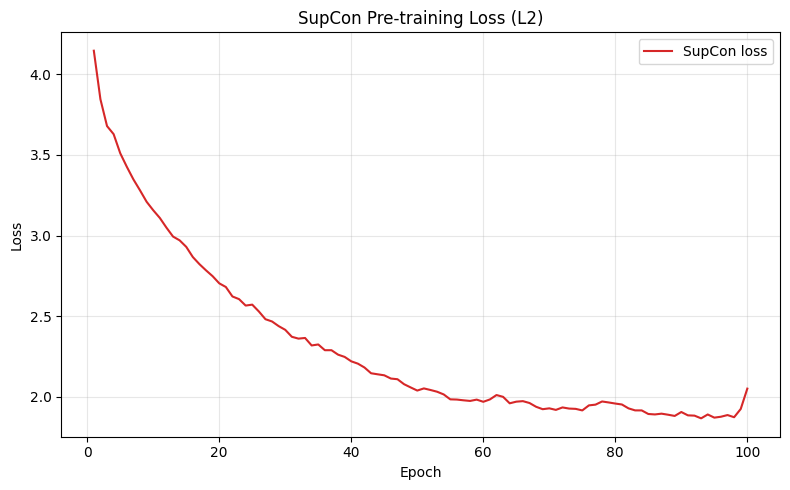

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(history['epoch'], history['loss'], label='SupCon loss', color='#d62728')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title(f'SupCon Pre-training Loss ({FEATURE_LAYER})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'ssl_supcon_loss_{FEATURE_LAYER}.png', dpi=150)
plt.show()

## 7. Proxy Evaluation

Two evaluations to check representation quality:

**7a. Shot-type classification on SS val set** — freeze encoder, train linear head on SS train,
evaluate on held-out val matches. Direct proxy for SupCon quality.

**7b. Linear probe on FineBadminton strategy labels** — cross-validated logistic regression.
Sanity-check that the representation transfers to the downstream task.

In [ ]:
import torch
from pathlib import Path
from src.config import MODELS_DIR

# Ensure FEATURE_LAYER and device are available
if 'FEATURE_LAYER' not in globals():
    FEATURE_LAYER = 'L2'
if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Path to the saved checkpoint
ckpt_path = MODELS_DIR / f'ssl_pretrained_supcon_{FEATURE_LAYER}.pt'

if ckpt_path.exists():
    print(f"Loading checkpoint: {ckpt_path}")
    # Setting weights_only=False to allow loading custom ExperimentConfig class
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)

    # Load states into models
    encoder.load_state_dict(checkpoint['encoder_state_dict'])
    projector.load_state_dict(checkpoint['projector_state_dict'])

    print("Weights loaded successfully.")
    if 'history' in checkpoint:
        epochs = checkpoint['history'].get('epoch', [])
        print(f"Checkpoint was saved at epoch {max(epochs) if epochs else 'unknown'}")
else:
    print(f"Error: Checkpoint not found at {ckpt_path}. Please ensure the training cell was completed.")

[INFO] ShuttleSet split='None': 9503 shots from whole-match skeletons across 10 match(es)


KeyboardInterrupt: 

In [ ]:
## 7a. Shot-Type Classification on SS Val Set
import sys, os
from pathlib import Path
if 'PROJECT_PATH' in globals() and str(PROJECT_PATH) not in sys.path:
    sys.path.insert(0, str(PROJECT_PATH))

from src.config import get_config, FEATURE_DIMS, UNIFIED_SHOT_TYPES
from src.data.dataset import ShuttleSetDataset
from src.config import SS_SKELETONS_GDINO, SS_SPLIT_JSON
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import joblib
import torch
import numpy as np

cfg = get_config('ssl_supcon')
cfg.data.shot_window = 32
if 'FEATURE_LAYER' not in globals():
    FEATURE_LAYER = 'L2'

def extract_embeddings(ds, enc, dev):
    enc.eval()
    embs, labs = [], []
    with torch.no_grad():
        for i in range(len(ds)):
            sample = ds[i]
            x, y = sample if isinstance(sample, tuple) else (sample, -1)
            if y < 0:
                continue
            emb = enc(x.unsqueeze(0).to(dev)).cpu().numpy()[0]
            embs.append(emb)
            labs.append(y)
    return np.array(embs), np.array(labs)

# Proxy eval splits — right-handed matches only
# Val uses held-out right-handed matches (NOT Kento — left-handed, different joint patterns)
PROXY_TRAIN = {
    "Anders_Antonsen_Viktor_Axelsen_HSBC_BWF_WORLD_TOUR_FINALS_2020_Finals",
    "Anthony_Sinisuka_GINTING_Anders_ANTONSEN_Indonesia_Masters_2020_Final",
    "Anthony_Sinisuka_GINTING_Viktor_AXELSEN _Indonesia_Masters_2020_SemiFinals",
    "CHOU_Tien_Chen_Anders_ANTONSEN_Fuzhou_Open_2019_Semi-finals",
}

PROXY_VAL = {
    "Anders_ANTONSEN_Jonatan_CHRISTIE Indonesia_Masters_2020_QuarterFinals",
    "CHEN_Long_CHOU_Tien_Chen_World_Tour_Finals_Group_Stage",
}

# SS train split
ss_train = ShuttleSetDataset(
    skeleton_dir=SS_SKELETONS_GDINO,
    shot_window=cfg.data.shot_window,
    feature_layer=FEATURE_LAYER,
    load_shot_types=True,
    split=None
)
ss_train.samples = [s for s in ss_train.samples if Path(s['skel_dir']).name in PROXY_TRAIN]
X_train, y_train = extract_embeddings(ss_train, encoder, device)
print(f"SS train embeddings: {X_train.shape}  ({len(set(y_train)) if len(y_train)>0 else 0} classes)")

# SS val split
ss_val = ShuttleSetDataset(
    skeleton_dir=SS_SKELETONS_GDINO,
    shot_window=cfg.data.shot_window,
    feature_layer=FEATURE_LAYER,
    load_shot_types=True,
    split=None
)
ss_val.samples = [s for s in ss_val.samples if Path(s['skel_dir']).name in PROXY_VAL]
X_val, y_val = extract_embeddings(ss_val, encoder, device)
print(f"SS val   embeddings: {X_val.shape}")

if len(X_train) > 0 and len(X_val) > 0:
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)

    clf = LogisticRegression(max_iter=2000, C=1.0)
    clf.fit(X_train_s, y_train)
    preds = clf.predict(X_val_s)

    macro_f1 = f1_score(y_val, preds, average='macro')
    print(f"\nSS Val Shot-Type Macro-F1: {macro_f1:.3f}")
    print(classification_report(y_val, preds, zero_division=0))

    shot_clf_path = MODELS_DIR / f'shot_type_clf_supcon_{FEATURE_LAYER}.joblib'
    joblib.dump({'clf': clf, 'scaler': scaler}, shot_clf_path)
    print(f'\nShot-type classifier saved: {shot_clf_path}')
else:
    print("Error: Training or Validation set is empty.")

[INFO] ShuttleSet split='None': 9503 shots from whole-match skeletons across 10 match(es)
SS train embeddings: (3463, 256)  (15 classes)
[INFO] ShuttleSet split='None': 9503 shots from whole-match skeletons across 10 match(es)
SS val   embeddings: (2949, 256)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



SS Val Shot-Type Macro-F1: 0.499
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       183
           1       0.47      0.65      0.54        34
           2       0.53      0.58      0.56       190
           3       0.31      0.40      0.35       141
           4       0.21      0.17      0.19        29
           5       0.92      0.87      0.90       308
           6       0.43      0.18      0.26       157
           7       0.59      0.87      0.70       435
           8       0.56      0.51      0.53       157
           9       0.37      0.30      0.33       125
          10       0.63      0.51      0.56       394
          11       0.72      0.69      0.70       417
          12       0.24      0.53      0.33        15
          13       0.32      0.06      0.11       109
          16       0.53      0.58      0.55       255

    accuracy                           0.61      2949
   macro avg       0.51      0.52      0.50   

In [ ]:
## 7b. Linear Probe on FineBadminton Strategy Labels
from src.data.dataset import FineBadmintonDataset
from src.config import FB_SKELETONS_GDINO_V2
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# IMPORTANT: Use GDINO v2 skeletons to match the SS encoder's extraction pipeline
fb_ds = FineBadmintonDataset(
    skeleton_dir=FB_SKELETONS_GDINO_V2,
    feature_layer=FEATURE_LAYER,
)
print(f"FineBadminton: {len(fb_ds)} samples")
print(f"Skeleton dir: {FB_SKELETONS_GDINO_V2}")

fb_embs, fb_labs = extract_embeddings(fb_ds, encoder, device)
print(f"Embeddings: {fb_embs.shape}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_f1s = []
for train_idx, test_idx in skf.split(fb_embs, fb_labs):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(fb_embs[train_idx])
    X_te = scaler.transform(fb_embs[test_idx])
    clf = LogisticRegression(max_iter=2000, C=1.0)
    clf.fit(X_tr, fb_labs[train_idx])
    preds = clf.predict(X_te)
    fold_f1s.append(f1_score(fb_labs[test_idx], preds, average='macro'))

print(f"\nFB Strategy Linear Probe Macro-F1: {np.mean(fold_f1s):.3f} +/- {np.std(fold_f1s):.3f}")
print(f"Per-fold: {[f'{f:.3f}' for f in fold_f1s]}")

[INFO] FineBadminton: loaded court homography from H_img_to_court_m.npy
[INFO] FineBadminton: 296 labeled shots across 40 rallies
  intercept: 108
  create_depth: 61
  defensive: 59
  passive: 50
  move_to_net: 18
FineBadminton: 296 samples
Embeddings: (296, 256)

FB Strategy Linear Probe Macro-F1: 0.107 +/- 0.002
Per-fold: ['0.104', '0.109', '0.109', '0.109', '0.105']
